In [1]:
import pandas as pd
import numpy as np

In [2]:
# Step 1: Create dataset
df = pd.DataFrame({
    "Area": [500, 600, 700, 800, 900, 1000,
             1100, 1200, 1300, 1400, 1500, 1600,
             1700, 1800, 1900, 2000, 750, 950,
             1250, 1550],
    "Bedrooms": [1, 1, 2, 2, 2, 2,
                 3, 3, 3, 3, 3, 4,
                 4, 4, 4, 4, 2, 2, 3, 3],
    "Bathrooms": [1, 1, 1, 1, 2, 2,
                  2, 2, 2, 2, 2, 3,
                  3, 3, 3, 3, 1, 2, 2, 3],
    "LocationScore": [1, 1, 2, 2, 3, 3,
                      3, 4, 4, 4, 4, 5,
                      5, 5, 5, 5, 2, 3, 4, 4],
    "Rent": [8000, 9000, 12000, 14000, 17000,
             19000, 22000, 25000, 27000, 30000,
             32000, 36000, 40000, 42000, 45000,
             48000, 13000, 18000, 28000, 34000]
})

In [3]:
df.head()

,Area,Bedrooms,Bathrooms,LocationScore,Rent
0,500,1,1,1,8000
1,600,1,1,1,9000
2,700,2,1,2,12000
3,800,2,1,2,14000
4,900,2,2,3,17000


In [4]:
# Step 2: Separate input and output
X = df[['Area','Bedrooms','Bathrooms','LocationScore']]
y = df['Rent']

In [5]:
# Step 3: Split training and testing data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    
)

In [6]:
# Step 4: Scale input features

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
# Step 5: Build deep learning model

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense

model = Sequential([
    Input(shape=(4,)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Step 6: Compile model

from tensorflow.keras.optimizers import Adam,SGD

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss="mse",
    metrics=["mae"]
)

In [9]:
# Step 7: Train model

history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=4, 
    validation_split=0.2,
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 219ms/step - loss: 782328256.0000 - mae: 25999.9160 - val_loss: 1039452800.0000 - val_mae: 30999.2930
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 782285504.0000 - mae: 25999.2031 - val_loss: 1039381056.0000 - val_mae: 30998.2148
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 782212800.0000 - mae: 25998.0684 - val_loss: 1039258368.0000 - val_mae: 30996.3672
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 782111552.0000 - mae: 25996.3750 - val_loss: 1039065344.0000 - val_mae: 30993.4570
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 781917888.0000 - mae: 25993.3340 - val_loss: 1038769664.0000 - val_mae: 30989.0039
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 781660992.0000 - mae: 25989.2090 - val_loss: 1038331904.0000 - val_mae: 30982.4082
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 781286592.0000 - mae: 25982.9863 - val_loss: 1037723264.0000 - val_mae: 30973.2363
Epoch 8/200


In [10]:
print("Model training completed!")

Model training completed!


In [11]:
# Step 8: Evaluate model

loss,mae = model.evaluate(X_test, y_test, verbose=0)

In [12]:
print("Test MAE:", round(mae, 2), "Rupees")

Test MAE: 4025.42 Rupees


In [13]:
# Step 9: Predict rent for a new house

new_house = pd.DataFrame({
    "Area": [1000],
    "Bedrooms": [3],
    "Bathrooms": [2],
    "LocationScore": [4]
})

In [14]:
new_house_scaled = scaler.transform(new_house)

In [15]:
predicted_rent = model.predict(new_house_scaled, verbose=0)[0][0]

In [16]:
print("Predicted monthly rent: Rs.", round(float(predicted_rent), 2))

Predicted monthly rent: Rs. 25459.26


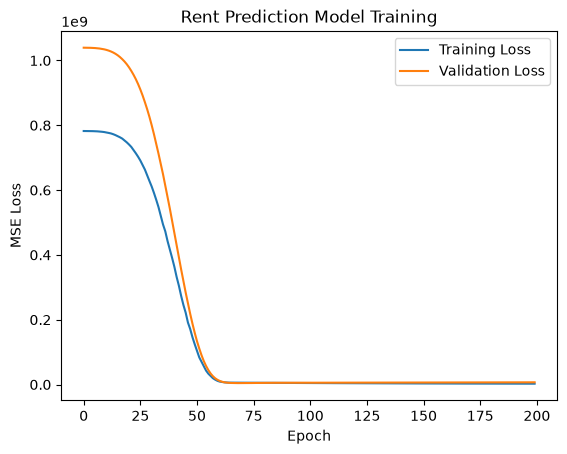

In [20]:
# Step 10: Plot training and validation loss
import matplotlib.pyplot as plt
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Rent Prediction Model Training")
plt.legend()
plt.show()

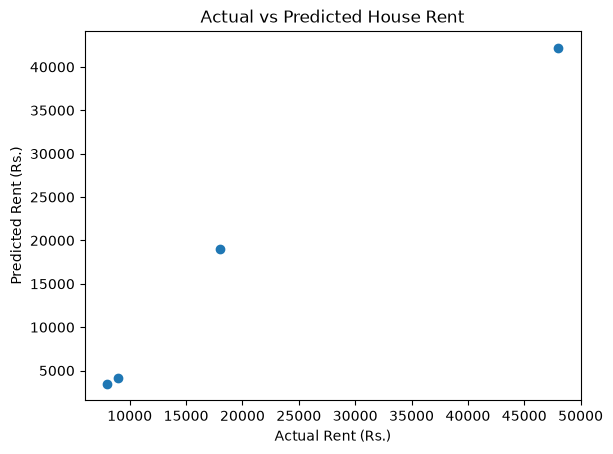

In [22]:
# Step 11: Compare actual and predicted rent

y_pred = model.predict(X_test, verbose=0).flatten()

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Rent (Rs.)")
plt.ylabel("Predicted Rent (Rs.)")
plt.title("Actual vs Predicted House Rent")
plt.show()